# Лекція: Навчання без учителя

## Огляд
Ласкаво просимо до цієї лекції про **навчання без учителя**, ключову гілку машинного навчання, де алгоритм вивчає закономірності з немаркованих даних. На відміну від навчання з учителем, тут немає заздалегідь визначених міток чи вихідних даних для керування моделлю. Натомість мета полягає в тому, щоб виявити приховані структури, зв’язки або групування в даних.

У цій лекції ми:
- Визначимо, що таке навчання без учителя та його цілі.
- Розглянемо ключові задачі навчання без учителя: **кластеризацію** та **зменшення розмірності**.
- обговоримо практичні приклади застосування

Почнімо!

## Що таке навчання без учителя?

Навчання без учителя передбачає тренування моделі на даних без явних міток чи цільових значень. Алгоритм має виводити закономірності чи структури, спираючись лише на вхідні дані. Це корисно, коли ми не знаємо, що шукаємо, або коли маркування даних є непрактичним.

### Основні Задачі
1. **Кластеризація**: Групування схожих точок даних разом (наприклад, сегментація клієнтів).
2. **Зменшення розмірності**: Зменшення кількості ознак із збереженням важливої інформації (наприклад, стиснення даних).
3. **Виявлення аномалій**: Ідентифікація рідкісних або незвичайних точок даних (наприклад, виявлення шахрайства).

### Поширені алгоритми
- **K-Means Кластеризація**: Розділяє дані на K кластерів.
- **MeanShift Кластеризація**: Розділяє дані на основі вказаноі варіаціі даних.
- **Аналіз головних компонентів (PCA)**: Зменшує розмірність.
- **t-SNE**: Зменшує розмірність
- **Автокодувальники**: Зменшення розмірності на основі нейронних мереж.
- **DBSCAN**: Кластеризація на основі щільності для нерегулярних форм.

Далі ми зосередимося на кластеризації та реалізуємо K-Means як практичний приклад.

## Застосування навчання без учителя

1. **Сегментація ринку**: Групування клієнтів за поведінкою для цільового маркетингу.
2. **Групування документів за змістом**
2. **Стиснення зображень**: Зменшення розмірності даних пікселів за допомогою PCA.
3. **Виявлення аномалій**: Ідентифікація відхилень у мережевому трафіку.

 

## Кластеризація

Кластеризація — це процес групування точок даних на основі їхньої схожості. Припускається, що точки в межах одного кластера більше схожі між собою, ніж із точками в інших кластерах.

### Кластеризація НЕ є трансформером даних

Коли ми говорили про навчання з учителем, будь-який алгоритм можна було представити як функцію $$y=f(x)$$, де наша мета — знайти оптимальні параметри 𝑓 для прогнозування 𝑦
на основі 𝑥
x. У випадку навчання без учителя, зокрема кластеризації, ця формула не застосовна, тому що кластеризація не вчиться відображати вхідні дані 𝑥 на певну категорію чи значення 𝑦. Натомість цей метод призначений для розбиття масиву даних на групи на основі їхньої схожості.

Після завершення кластеризації ми не отримуємо 'навчену модель' у тому сенсі, як у навчанні з учителем, хоча деякі алгоритми (наприклад, K-Means) зберігають певні параметри, такі як центроїди кластерів. Однак ці параметри не узагальнюють дані так, як це робить
𝑓(𝑥). Можна сказати, що для повністю нового набору даних кластеризацію зазвичай доводиться виконувати заново, оскільки вона сильно залежить від структури конкретного набору.

### Кластеризація K-Means
K-Means — один із найпростіших і найпопулярніших алгоритмів кластеризації. Ось як він працює:
1. Виберіть кількість кластерів, **K**.
2. Випадково ініціалізуйте **K** центроїдів.
3. Призначте кожну точку даних до найближчого центроїда.
4. Перерахуйте центроїди як середнє значення призначених точок.
5. Повторюйте кроки 3–4, поки центроїди не стабілізуються.

Давайте реалізуємо K-Means за допомогою бібліотеки `scikit-learn` у Python.

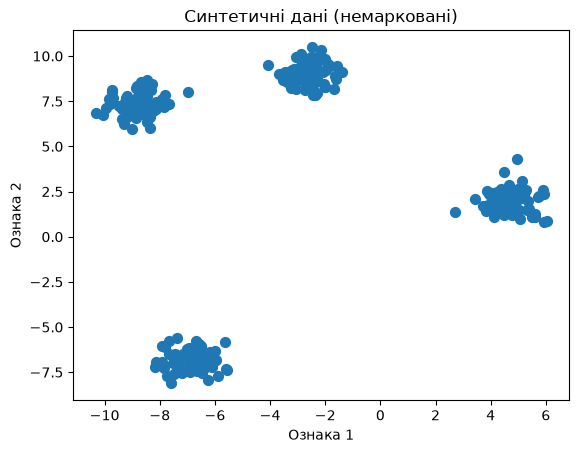

In [2]:
# Імпорт необхідних бібліотек
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Генерація синтетичних даних
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Візуалізація даних
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title('Синтетичні дані (немарковані)')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.show()

### Пояснення коду
- Ми використовуємо `make_blobs` для створення синтетичного набору даних із 300 точок і 4 природними кластерами.
- Точкова діаграма показує дані без міток, імітуючи реальний сценарій навчання без учителя.

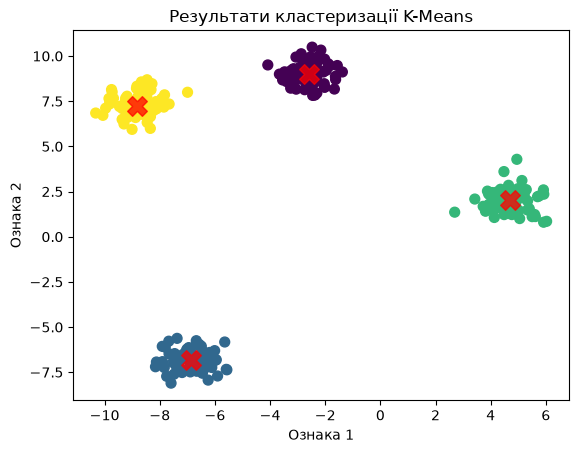

In [3]:
# Застосування кластеризації K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Отримання призначень кластерів і центроїдів
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Візуалізація результатів
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title('Результати кластеризації K-Means')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.show()

### Пояснення результатів
- Жовті, фіолетові, зелені та сині точки представляють 4 кластери, визначені K-Means.
- Червоні маркери 'X' показують центроїди кожного кластера.
- Алгоритм успішно згрупував схожі точки разом!

### ✅ Переваги:
- Простий у реалізації та швидкий в обчисленнях (O(nkT), де *n* – кількість точок, *k* – кількість кластерів, *T* – кількість ітерацій).
- Добре працює на великих наборах даних.
- Ефективний для сферичних кластерів зі схожими розмірами.

### ❌ Недоліки:
- Потрібно заздалегідь задавати кількість кластерів (*k*).
- Чутливий до початкового вибору центрів кластерів (може застрягати в локальних мінімумах).
- Погано працює з кластерами нестандартної форми або різної густини.
- Вразливий до викидів, оскільки використовує середнє значення.

In [4]:
#@title Візуалізація навчання KMeans
import numpy as np
from matplotlib.animation import FuncAnimation
from sklearn.datasets import make_blobs

import matplotlib.pyplot as plt
from IPython.display import HTML

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=2, random_state=42)

# Generate synthetic data
np.random.seed(41)

# Initialize centroids randomly
k = 4
centroids = X[np.random.choice(X.shape[0], k, replace=False)]

# Function to assign points to the nearest centroid
def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

# Function to update centroids
def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

# Prepare for animation
fig, ax = plt.subplots()
ax.axis('equal')
colors = ['r', 'g', 'b', 'y']
sc = ax.scatter(X[:, 0], X[:, 1], s=10)
centroid_sc = ax.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=100)

def init():
    sc.set_offsets(X)
    centroid_sc.set_offsets(centroids)
    return sc, centroid_sc

def update(frame):
    global centroids
    labels = assign_clusters(X, centroids)
    sc.set_color([colors[label] for label in labels])
    centroid_sc.set_offsets(centroids)
    centroids = update_centroids(X, labels, k)
    return sc, centroid_sc

ani = FuncAnimation(fig, update, frames=10, init_func=init, blit=True, repeat=False)
plt.close()

# Display the animation inline in the notebook
HTML(ani.to_jshtml())

## Вибір оптимальної кількості кластерів

Як ми дізналися, що **K=4** — правильний вибір? Один із поширених методів — **метод ліктя**, який відображає суму квадратів у межах кластера (WCSS) залежно від K.

Давайте це обчислимо.

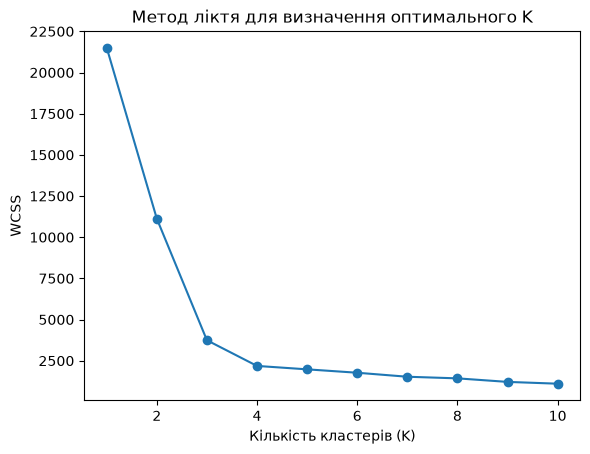

In [5]:
# Обчислення WCSS для різних значень K
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Побудова кривої ліктя
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Метод ліктя для визначення оптимального K')
plt.xlabel('Кількість кластерів (K)')
plt.ylabel('WCSS')
plt.show()

### Інтерпретація кривої ліктя
- Точка 'ліктя' (де WCSS зменшується повільніше) вказує на оптимальне K.
- Тут K=4 виглядає розумним, що підтверджує наш попередній вибір.

## Кластеризація Mean Shift

**Mean Shift** — це алгоритм кластеризації, який не вимагає заздалегідь визначеної кількості кластерів (K). Він працює, зсуваючи точки до областей із найбільшою щільністю даних, доки вони не зійдуться до центрів кластерів.

### Як працює Mean Shift
1. Для кожної точки даних визначається вікно (радіус).
2. Обчислюється середнє значення точок у межах вікна.
3. Центр вікна зсувається до цього середнього.
4. Процес повторюється, поки центри не стабілізуються.
5. Точки, що зійшлися до одного центру, утворюють кластер.

Давайте реалізуємо Mean Shift на тому ж синтетичному наборі даних.

Кількість кластерів, визначених Mean Shift: 4


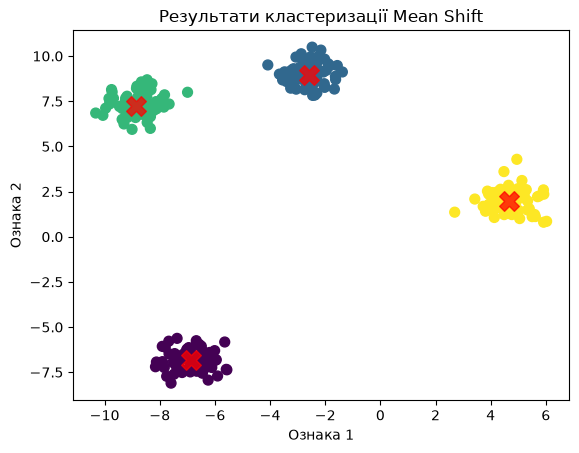

In [6]:
# Імпорт Mean Shift
from sklearn.cluster import MeanShift, estimate_bandwidth

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Оцінка ширини вікна (bandwidth) автоматично
bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=300)

# Застосування Mean Shift
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
# ms = MeanShift(bandwidth=10, bin_seeding=True)
ms.fit(X)

# Отримання міток кластерів і центроїдів
labels_ms = ms.labels_
cluster_centers_ms = ms.cluster_centers_

# Кількість кластерів
n_clusters_ms = len(np.unique(labels_ms))
print(f'Кількість кластерів, визначених Mean Shift: {n_clusters_ms}')

# Візуалізація результатів
plt.scatter(X[:, 0], X[:, 1], c=labels_ms, s=50, cmap='viridis')
plt.scatter(cluster_centers_ms[:, 0], cluster_centers_ms[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title('Результати кластеризації Mean Shift')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.show()

### ✅ Переваги:
- Не потребує задання кількості кластерів (*k*).
- Агрегує точки в густонаселені області, що допомагає виявляти природні структури в даних.

### ❌ Недоліки:
- Обчислювально затратний (O(n²) або гірше, залежно від вибору ядра).
- Вибір параметра радіуса ядра (bandwidth) критично впливає на якість кластеризації.
- Погано працює на великих наборах даних через високу складність.
 

## Кластеризація DBSCAN

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) — це алгоритм, який групує точки на основі щільності й може виявляти шум (аномалії). Він не вимагає вказівки кількості кластерів.

### Як працює DBSCAN
1. Визначаються два параметри: **eps** (максимальна відстань між точками в одному кластері) і **min_samples** (мінімальна кількість точок для утворення кластера).
2. Точки з достатньою кількістю сусідів у радіусі `eps` стають ядрами кластера.
3. Кластери розширюються, включаючи сусідні точки.
4. Точки, які не належать до жодного кластера, позначаються як шум.

Реалізуємо DBSCAN нижче.

Кількість кластерів, визначених DBSCAN: 4


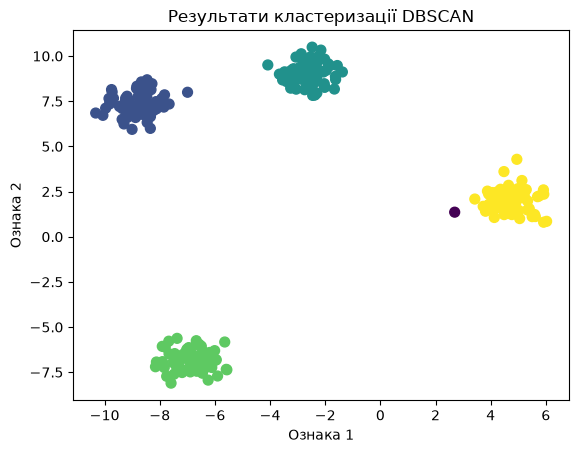

In [7]:
# Імпорт DBSCAN
from sklearn.cluster import DBSCAN

# Застосування DBSCAN
dbscan = DBSCAN(eps=1, min_samples=5)
dbscan.fit(X)

# Отримання міток кластерів (шум позначено як -1)
labels_db = dbscan.labels_

# Кількість кластерів (без шуму)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print(f'Кількість кластерів, визначених DBSCAN: {n_clusters_db}')

# Візуалізація результатів
plt.scatter(X[:, 0], X[:, 1], c=labels_db, s=50, cmap='viridis')
plt.title('Результати кластеризації DBSCAN')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.show()

### Пояснення результатів
- Кольорові точки належать до кластерів, а сірі (або -1) — це шум.
- DBSCAN добре працює з нерегулярними формами кластерів і може виявляти аномалії.
- Виклик: правильний вибір `eps` і `min_samples` залежить від даних.

### ✅ Переваги:
- Автоматично визначає кількість кластерів.
- Добре працює з кластерами довільної форми та різної густини.
- Стійкий до викидів (класифікує їх як "шум").

### ❌ Недоліки:
- Потребує налаштування двох параметрів: ε (радіус сусідства) і *minPts* (мінімальна кількість точок у кластері).
- Погано працює, якщо щільність кластерів сильно змінюється (вибір *ε* стає проблематичним).
- Часова складність O(n log n), але може зрости до O(n²) у гіршому випадку.

## Порівняння алгоритмів на різних даних

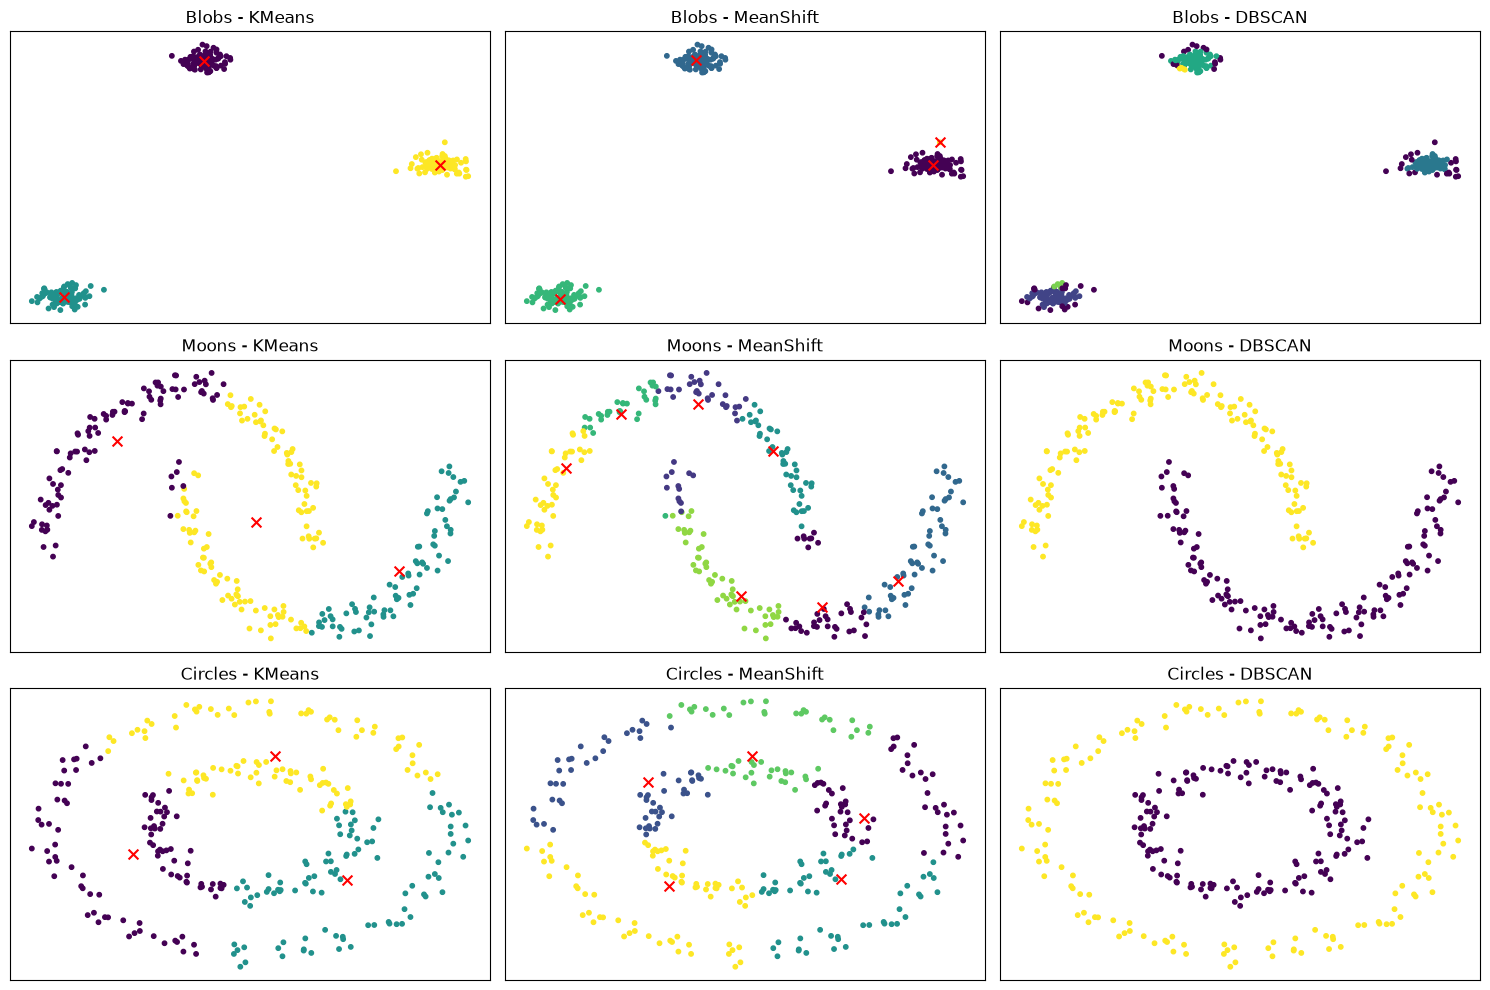

In [8]:
import numpy as np
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, MeanShift, DBSCAN

import matplotlib.pyplot as plt

# Generate datasets
datasets = [
    ("Blobs", make_blobs(n_samples=300, centers=3, cluster_std=0.4, random_state=42)),
    ("Moons", make_moons(n_samples=300, noise=0.05, random_state=42)),
    ("Circles", make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42))
]

# Clustering algorithms
clustering_algorithms = [
    ("KMeans", KMeans(n_clusters=3, random_state=42)),
    ("MeanShift", MeanShift(bandwidth=0.5)),
    ("DBSCAN", DBSCAN(eps=0.2))
]

# Plotting
fig, axes = plt.subplots(len(datasets), len(clustering_algorithms), figsize=(15, 10))
for row, (dataset_name, (X, _)) in enumerate(datasets):
    for col, (algo_name, algo) in enumerate(clustering_algorithms):
        algo.fit(X)
        labels = algo.labels_
        axes[row, col].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=10)
        axes[row, col].set_title(f"{dataset_name} - {algo_name}")
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

        # Plot centroids if available
        if hasattr(algo, 'cluster_centers_'):
            centroids = algo.cluster_centers_
            axes[row, col].scatter(centroids[:, 0], centroids[:, 1], c='red', s=50, marker='x', label='Centroids')

plt.tight_layout()
plt.show()

## Зменшення розмірності

Зменшення розмірності — це техніка навчання без учителя, яка зменшує кількість ознак у наборі даних, зберігаючи при цьому якомога більше важливої інформації. Це корисно для візуалізації, зменшення обчислювальних витрат і уникнення «прокляття розмірності».

Ми розглянемо два популярні методи: **Аналіз головних компонентів (PCA)** і **t-SNE**.

## Аналіз головних компонентів (PCA)

**PCA** — це лінійний метод, який трансформує дані в новий простір, де осі (головні компоненти) представляють напрями максимальної дисперсії.

### Як працює PCA
1. Стандартизуйте дані (щоб ознаки мали однакову шкалу).
2. Обчисліть коваріаційну матрицю даних.
3. Знайдіть власні вектори й власні значення — це головні компоненти.
4. Проектуйте дані на перші k компонентів із найбільшою дисперсією.

Реалізуємо PCA для візуалізації наших даних у 2D.

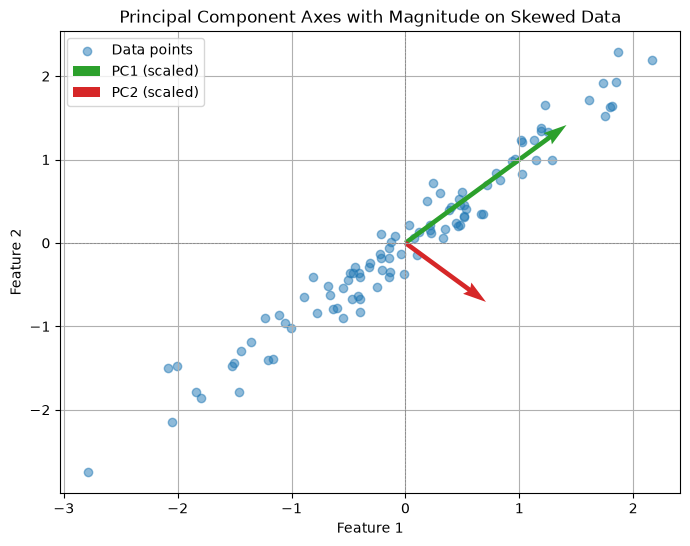

In [9]:
#@title Візуалізація головних компонента (principal components)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Generate synthetic skewed 2D data
np.random.seed(42)
x = np.random.randn(100) * 2  # Scale one dimension
y = x * 0.5 + np.random.randn(100) * 0.2  # Create correlation and add noise
data = np.column_stack((x, y))

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Perform PCA
pca = PCA(n_components=2)
pca.fit(data_scaled)

# Get principal components and explained variance ratio
components = pca.components_
mean = pca.mean_
explained_variance = pca.explained_variance_ratio_

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], alpha=0.5, label="Data points")

# Plot principal component axes with magnitude
for i, (component, variance) in enumerate(zip(components, explained_variance)):
    plt.quiver(
        mean[0], mean[1], component[0] * 2 / (i+1), component[1] * 2 / (i+1),
        angles='xy', scale_units='xy', scale=1, color=f"C{i+2}", label=f"PC{i+1} (scaled)"
    )

plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Principal Component Axes with Magnitude on Skewed Data")
plt.legend()
plt.grid()
plt.show()
 

## Трансформовані дані

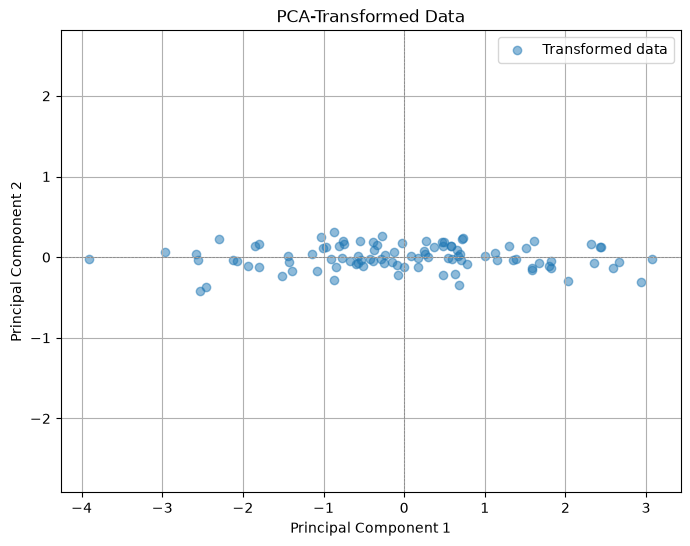

In [10]:
#@title Трансформовані дані

# Transform the data using PCA
data_pca = pca.transform(data_scaled)

# Plot the PCA-transformed data
plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.5, label="Transformed data")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA-Transformed Data")
plt.legend()
plt.axis('equal')
plt.grid()
plt.show()

### Пояснення результатів
- Дані спроектовано на дві головні компоненти, які зберігають максимальну дисперсію.
- Показник поясненої дисперсії вказує, яку частину інформації збережено.
- Перевага PCA: простота й швидкість. Недолік: припускає лінійність.

## Реальний приклад MNIST

Спробуєм використати PCA для зниження розмірності даних MNIST, для подальшоі класифікаціі.
 

In [11]:
import pandas as pd

# Ці дані так само вже зберігаються в середі google colab
train_data_path = 'mnist_train_small.csv'
test_data_path = 'mnist_test.csv'

# В данному випадку хедера в таблицях нема. Значення категоріі зберігається
# в першій колонці.
train_data = pd.read_csv(train_data_path, header=None)
test_data = pd.read_csv(test_data_path, header=None)
 

In [12]:
# Візуалізуємо наші дані
test_data.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


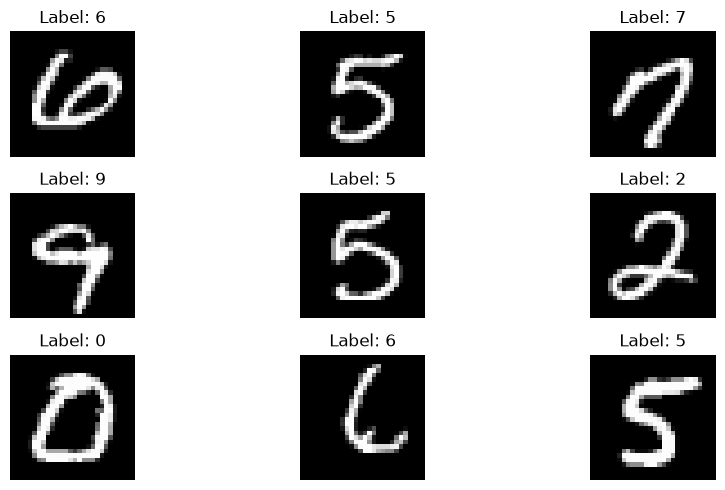

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Розділяємо наші ознаки від вчителя
X_train = train_data.drop(0, axis=1).values
y_train = train_data[0].values

X_test = test_data.drop(0, axis=1).values
y_test = test_data[0].values

# Visualize some samples
plt.figure(figsize=(10, 5))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
#@title  Нормалізація даних

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

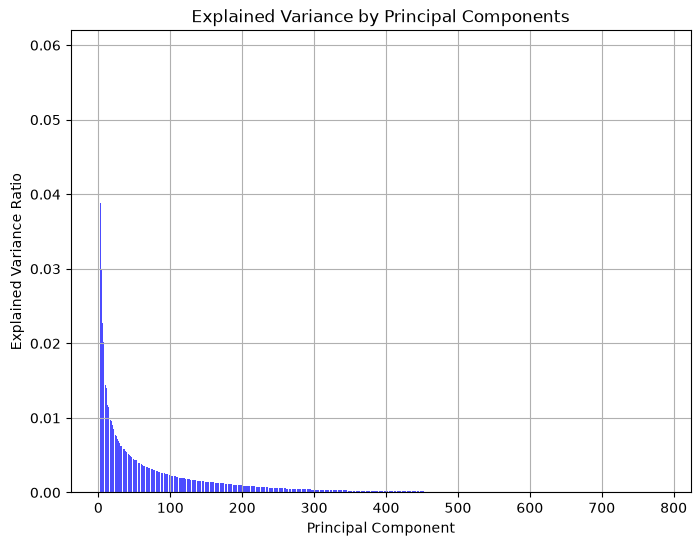

In [15]:
#@title Візуалізація варіаціі по кожній із компонент

pca_for_vis = PCA()
pca_for_vis.fit(X_train_scaled)

explained_variance = pca_for_vis.explained_variance_ratio_

plt.figure(figsize=(8, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='b')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid()
plt.show()

## Зниження розмірності

In [16]:
#@title Зниження розмірності

from sklearn.decomposition import PCA

# Залишимо N трансформованих ознак, котрі покривають 90% варіаціі даних.
pca = PCA(n_components=0.9)
pca.fit(X_train_scaled)
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('Shape before PCA:', X_train_scaled.shape)
print('Shape after PCA:', X_train_pca.shape)

Shape before PCA: (20000, 784)
Shape after PCA: (20000, 216)


In [17]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Train an SVM classifier
clf = RandomForestClassifier(n_estimators=10, random_state=42)
clf.fit(X_train_scaled, y_train)

# Train an SVM classifier
clf_pca = RandomForestClassifier(n_estimators=10, random_state=42)
clf_pca.fit(X_train_pca, y_train)

# Make predictions
y_pred = clf.predict(X_test_scaled)
y_pred_pca = clf_pca.predict(X_test_pca)

# Evaluate the classifier
print(f"Accuracy no pca: {accuracy_score(y_test, y_pred)}")
print(f"Accuracy with pca: {accuracy_score(y_test, y_pred_pca)}")

Accuracy no pca: 0.9257
Accuracy with pca: 0.8691
